# Instalação

In [ ]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.0.1+cu118
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
time: 25.4 s (started: 2023-09-02 00:12:52 +00:00)


In [ ]:
!cat /proc/cpuinfo
!df -h
!cat /proc/meminfo
!nvidia-smi
!nvidia-smi --query-gpu=memory.total

time: 3min (started: 2023-09-02 00:13:17 +00:00)
processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 79
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2199.998
cache size	: 56320 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch invpcid_single ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm rdseed adx smap xsaveopt arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmio_stale_data retbleed
bogomips	: 4399

In [ ]:
!pip install nvidia-ml-py3
!pip install ipython-autotime
!apt install sysstat
%load_ext autotime

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
sysstat is already the newest version (12.5.2-2ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 16 not upgraded.
The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 12.6 s (started: 2023-09-02 01:02:52 +00:00)


In [ ]:
# !sar -q 1 100 >> /tmp/report_cpu_queue.txt
# !sar -uq 1 1 | awk 'BEGIN {printf "%-10s\n","%idle"} NR>3 {printf "%-10s\n", $6}'
# !sar -uq 1 1
# !paste <(sar -u 1 5) <(sar -q 1 5) >> /tmp/sar.out

time: 474 µs (started: 2023-09-02 01:03:16 +00:00)


# Utils

In [ ]:
import psutil
import os
from torch_geometric.profile import get_cpu_memory_from_gc, get_stats_summary

pid = os.getpid()
process = psutil.Process(pid)

def print_memory_and_cpu():
  # Get the CPU usage as a percentage
  cpu_percent = psutil.cpu_percent()

  cpu_percent_per_core = psutil.cpu_percent(percpu=True)

  # Get the memory usage in bytes
  memory_bytes = process.memory_info().rss

  # Convert the memory usage to MB or GB (optional)
  memory_mb = memory_bytes / 1024 / 1024
  memory_gb = memory_bytes / 1024 / 1024 / 1024

  cpu_gc = get_cpu_memory_from_gc() / 1024 / 1024 / 1024
  # stats_summary = get_stats_summary(stats_list=)

  # Return the results
  return cpu_percent, memory_gb, cpu_gc, cpu_percent_per_core


time: 2.09 ms (started: 2023-09-02 01:03:16 +00:00)


In [ ]:
import time

def measure_queue_length():
    start_time = time.perf_counter()
    for i in range(100000):
        pass
    end_time = time.perf_counter()
    cpu_time = end_time - start_time
    wall_time = time.process_time()
    return (cpu_time / wall_time) - 1

queue_length = measure_queue_length()
print("CPU queue length:", queue_length)


CPU queue length: -0.9999981774153688
time: 8.78 ms (started: 2023-09-02 01:03:17 +00:00)


In [ ]:
def print_psi():
  # Get the overall PSI values
  psi = psutil.swap_memory().psi

  # Print the PSI values
  print("Overall PSI values: ", psi)

  # Iterate over all running processes and print their PSI values
  for proc in psutil.process_iter(['pid', 'name']):
      io_counters = proc.io_counters()
      if io_counters:
          print(f"Process {proc.pid} ({proc.info['name']}): {io_counters.psi}")

time: 887 µs (started: 2023-09-02 01:03:17 +00:00)


In [ ]:
import pynvml

def monitor_gpu():
    try:
        pynvml.nvmlInit()

        # Get the handle of the first GPU
        handle = pynvml.nvmlDeviceGetHandleByIndex(0)

        # Get the GPU name
        name = pynvml.nvmlDeviceGetName(handle)

        # Get the current GPU utilization
        utilization = pynvml.nvmlDeviceGetUtilizationRates(handle)
        gpu_utilization = utilization.gpu

        # Get the current GPU memory usage
        meminfo = pynvml.nvmlDeviceGetMemoryInfo(handle)
        gpu_used_memory = meminfo.used

        # Print the results
        # print(f"{name.decode('utf-8')} GPU Utilization: {gpu_utilization}% - GPU Memory: {gpu_used_memory / (1024 * 1024)} MB")

        pynvml.nvmlShutdown()
        return gpu_utilization, gpu_used_memory
    except:
      return 0,0

time: 980 µs (started: 2023-09-02 01:03:18 +00:00)


In [ ]:
# Helper function for visualization.
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

time: 6.92 ms (started: 2023-09-02 01:03:18 +00:00)


In [ ]:
# /etc/cron.d/sysstat
!service cron start

cron: unrecognized service
time: 111 ms (started: 2023-09-02 01:03:18 +00:00)


In [ ]:
!sar -f /var/log/sysstat/sa16

Cannot open /var/log/sysstat/sa16: No such file or directory
time: 107 ms (started: 2023-09-02 01:03:18 +00:00)


In [ ]:
!sudo service sysstat restart


time: 107 ms (started: 2023-09-02 01:03:18 +00:00)


time: 124 ms (started: 2023-09-02 01:03:18 +00:00)


# Load Dataset

In [ ]:
from torch_geometric.datasets import Amazon
import torch_geometric.transforms as T

transform = T.RandomNodeSplit()

dataset = Amazon(root="data/Amazon", name="Computers", transform=transform)


time: 55 ms (started: 2023-09-02 01:03:18 +00:00)


In [ ]:
print(dataset.get_summary())

print(dataset.data.num_node_features)

Amazon (#graphs=1):
+------------+----------+----------+
|            |   #nodes |   #edges |
|------------+----------+----------|
| mean       |    13752 |   491722 |
| std        |      nan |      nan |
| min        |    13752 |   491722 |
| quantile25 |    13752 |   491722 |
| median     |    13752 |   491722 |
| quantile75 |    13752 |   491722 |
| max        |    13752 |   491722 |
+------------+----------+----------+
767
time: 10.4 ms (started: 2023-09-02 01:03:18 +00:00)


/usr/local/lib/python3.10/dist-packages/torch_geometric/data/in_memory_dataset.py:189: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


time: 23.2 ms (started: 2023-09-02 01:03:18 +00:00)


# Imports

In [ ]:
import torch
from tabulate import tabulate

use_cuda_if_available = False

time: 901 µs (started: 2023-09-02 01:03:18 +00:00)


In [ ]:
header = []
header.append(['Dataset', 'N. Graphs', 'N. Features', 'N. Classes', 'N. Nodes', 'N. Edges', 'Avg. Node Degree', 'N. Training Nodes', 'Training node label rate', 'Has isolated nodes', 'Has self-loops', 'Undirected'])
print()

data = dataset[0]  # Get the first graph object.

print()
print(f'data: {data}')
print(f'train mask: {data.train_mask}')

header.append([dataset, len(dataset), dataset.num_features, dataset.num_classes, data.num_nodes, data.num_edges,
               f'{data.num_edges / data.num_nodes:.2f}', data.train_mask.sum(), f'{int(data.train_mask.sum()) / data.num_nodes:.3f}',
               data.has_isolated_nodes(), data.has_self_loops(), data.is_undirected()])

print(tabulate(header, tablefmt="simple"))
# print(tabulate(header, tablefmt="latex"))



data: Data(x=[13752, 767], edge_index=[2, 491722], y=[13752], train_mask=[13752], val_mask=[13752], test_mask=[13752])
train mask: tensor([True, True, True,  ..., True, True, True])
-----------------  ---------  -----------  ----------  --------  --------  ----------------  -----------------  ------------------------  ------------------  --------------  ----------
Dataset            N. Graphs  N. Features  N. Classes  N. Nodes  N. Edges  Avg. Node Degree  N. Training Nodes  Training node label rate  Has isolated nodes  Has self-loops  Undirected
AmazonComputers()  1          767          10          13752     491722    35.76             12252              0.891                     True                False           True
-----------------  ---------  -----------  ----------  --------  --------  ----------------  -----------------  ------------------------  ------------------  --------------  ----------
time: 146 ms (started: 2023-09-02 01:03:18 +00:00)


# Clustering Data

In [ ]:
from torch_geometric.loader import ClusterData, ClusterLoader

torch.manual_seed(12345)
cluster_data = ClusterData(data, num_parts=128)  # 1. Create subgraphs.
train_loader = ClusterLoader(cluster_data, batch_size=32, shuffle=True)  # 2. Stochastic partioning scheme.

print()
total_num_nodes = 0
for step, sub_data in enumerate(train_loader):
    print(f'Step {step + 1}:')
    print('----------------------------')
    print(f'Number of nodes in the current batch: {sub_data.num_nodes}')
    print(f'Number of edges in the current batch: {sub_data.num_edges}')
    print(sub_data)
    print()
    total_num_nodes += sub_data.num_nodes

print(f'Iterated over {total_num_nodes} of {data.num_nodes} nodes!')

Computing METIS partitioning...



Step 1:
----------------------------
Number of nodes in the current batch: 3421
Number of edges in the current batch: 67454
Data(x=[3421, 767], y=[3421], train_mask=[3421], val_mask=[3421], test_mask=[3421], edge_index=[2, 67454])

Step 2:
----------------------------
Number of nodes in the current batch: 3435
Number of edges in the current batch: 64450
Data(x=[3435, 767], y=[3435], train_mask=[3435], val_mask=[3435], test_mask=[3435], edge_index=[2, 64450])

Step 3:
----------------------------
Number of nodes in the current batch: 3472
Number of edges in the current batch: 78330
Data(x=[3472, 767], y=[3472], train_mask=[3472], val_mask=[3472], test_mask=[3472], edge_index=[2, 78330])

Step 4:
----------------------------
Number of nodes in the current batch: 3424
Number of edges in the current batch: 52530
Data(x=[3424, 767], y=[3424], train_mask=[3424], val_mask=[3424], test_mask=[3424], edge_index=[2, 52530])

Iterated over 13752 of 13752 nodes!
time: 925 ms (started: 2023-09-02 0

Done!


# GCN

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = SAGEConv(dataset.num_node_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): SAGEConv(767, 16, aggr=mean)
  (conv2): SAGEConv(16, 10, aggr=mean)
)
time: 15.8 ms (started: 2023-09-02 01:03:19 +00:00)


# Evaluate and Visualize

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
print ('Before execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)

Before execution: 

63.6 6.755836486816406 0.32839525397866964 [76.8, 50.4]
time: 10.7 s (started: 2023-09-02 01:03:19 +00:00)


In [ ]:
from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

model = GCN(hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()

      for sub_data in train_loader:  # Iterate over each mini-batch.
          out = model(sub_data.x, sub_data.edge_index)  # Perform a single forward pass.
          loss = criterion(out[sub_data.train_mask], sub_data.y[sub_data.train_mask])  # Compute the loss solely based on the training nodes.
          loss.backward()  # Derive gradients.
          optimizer.step()  # Update parameters based on gradients.
          optimizer.zero_grad()  # Clear gradients.

def test():
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.

      accs = []
      for mask in [data.train_mask, data.val_mask, data.test_mask]:
          correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
          accs.append(int(correct.sum()) / int(mask.sum()))  # Derive ratio of correct predictions.
      return accs
# print(f'Epoch\tTrain Acc\tVal Acc\tTest Acc\tCPU Percent\tMemory Use\tGarbage Collector')
results = []
results_formatted = []
results_formatted.append(['Epoch\t', 'TrainAcc.\t', 'ValAcc.\t', 'CPUPercent.\t', 'MemoryUse\t', 'GarbageCollector\t\n'])

for epoch in range(1, 101):
    loss = train()
    train_acc, val_acc, test_acc = test()
    cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
    results.append([epoch, train_acc, test_acc, cpu_percent,memory_mb, cpu_gc])
    results_formatted.append([f'{epoch:03d}\t', f'{train_acc:.3f}\t', f'{test_acc:.3f}\t', f'{cpu_percent:.3f}\t', f'{memory_mb:.3f}\t', f'{cpu_gc:.3f}\t\n'])
    print(f'{epoch:03d}')
print (results)

<IPython.core.display.Javascript object>

001
002
003
004
005
006
007
008
009
010
011
012
013
014
015
016
017
018
019
020
021
022
023
024
025
026
027
028
029
030
031
032
033
034
035
036
037
038
039
040
041
042
043
044
045
046
047
048
049
050
051
052
053
054
055
056
057
058
059
060
061
062
063
064
065
066
067
068
069
070
071
072
073
074
075
076
077
078
079
080
081
082
083
084
085
086
087
088
089
090
091
092
093
094
095
096
097
098
099
100
[[1, 0.1868266405484819, 0.187, 82.0, 0.8007354736328125, 0.16640828922390938], [2, 0.037300032647730984, 0.043, 51.9, 0.8007354736328125, 0.16640828922390938], [3, 0.43747959516813584, 0.441, 52.0, 0.8007354736328125, 0.16640828922390938], [4, 0.46408749591903364, 0.468, 52.1, 0.8007354736328125, 0.16640828922390938], [5, 0.3712047012732615, 0.386, 53.0, 0.8007354736328125, 0.16640828922390938], [6, 0.46963761018609207, 0.477, 91.4, 0.8007354736328125, 0.16640828922390938], [7, 0.3948743062357166, 0.41, 52.1, 0.8007354736328125, 0.16640828922390938], [8, 0.457639569049951, 0.463, 52.1, 0.8007

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
print ('After execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)

After execution: 

57.1 0.800994873046875 0.16640828922390938 [15.4, 100.0]
time: 126 ms (started: 2023-09-02 00:12:52 +00:00)


In [ ]:
from tabulate import tabulate

print(tabulate(results_formatted, tablefmt="latex"))

\begin{tabular}{llllll}
\hline
 Epoch & TrainAcc. & ValAcc. & CPUPercent. & MemoryUse & GarbageCollector \\
 001   & 0.187     & 0.187   & 82.000      & 0.801     & 0.166            \\
 002   & 0.037     & 0.043   & 51.900      & 0.801     & 0.166            \\
 003   & 0.437     & 0.441   & 52.000      & 0.801     & 0.166            \\
 004   & 0.464     & 0.468   & 52.100      & 0.801     & 0.166            \\
 005   & 0.371     & 0.386   & 53.000      & 0.801     & 0.166            \\
 006   & 0.470     & 0.477   & 91.400      & 0.801     & 0.166            \\
 007   & 0.395     & 0.410   & 52.100      & 0.801     & 0.166            \\
 008   & 0.458     & 0.463   & 52.100      & 0.801     & 0.166            \\
 009   & 0.416     & 0.430   & 51.600      & 0.801     & 0.166            \\
 010   & 0.448     & 0.451   & 52.800      & 0.801     & 0.166            \\
 011   & 0.447     & 0.449   & 91.300      & 0.801     & 0.166            \\
 012   & 0.411     & 0.428   & 51.800      & 

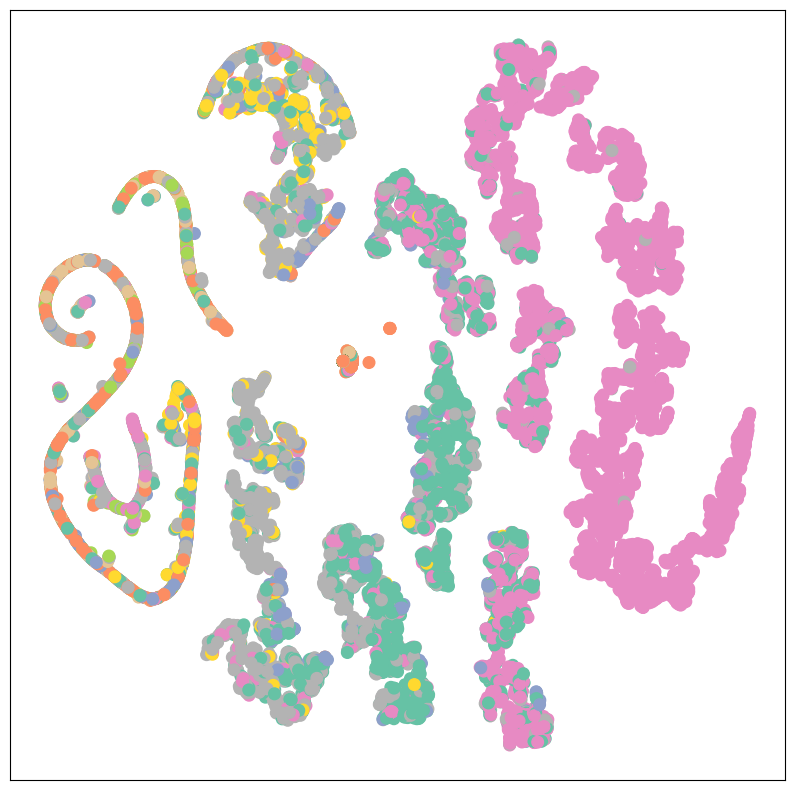

In [ ]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

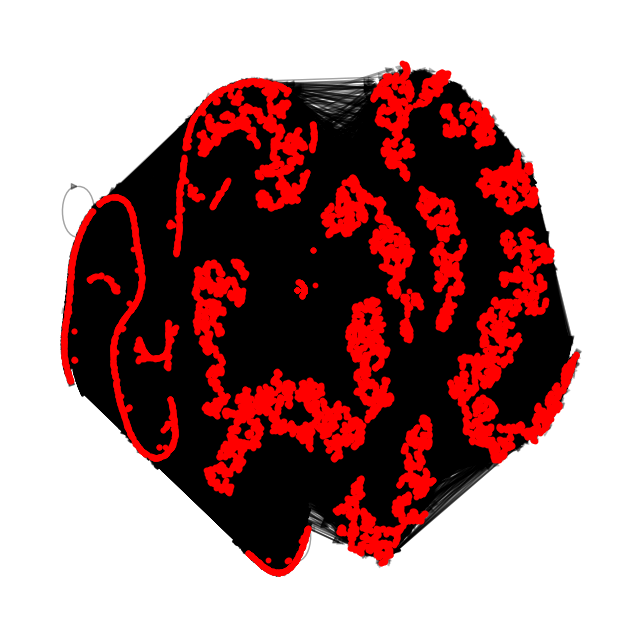

time: 46min 33s (started: 2023-09-02 00:16:18 +00:00)


In [ ]:
import networkx as nx
from torch_geometric.utils import to_networkx

# Obtenha as embeddings dos nós do grafo
with torch.no_grad():
    embeddings = model(dataset[0].x, dataset[0].edge_index)
    embeddings = embeddings.numpy()

# Reduza a dimensionalidade das embeddings usando o t-SNE
tsne = TSNE(n_components=2)
embeddings = tsne.fit_transform(embeddings)

# Obtenha o grafo em formato NetworkX
G = to_networkx(dataset[0])

# Plote os nós e arestas usando o Matplotlib
plt.figure(figsize=(8,8))
pos = {i: embeddings[i] for i in range(len(G.nodes))}
nx.draw_networkx_nodes(G, pos=pos, node_size=10, node_color='r')
nx.draw_networkx_edges(G, pos=pos, alpha=0.2)
plt.axis('off')
plt.show()

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
print ('After execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)

After execution: 

62.4 6.544792175292969 0.21657195314764977 [64.2, 60.6]
time: 10.8 s (started: 2023-09-02 01:03:05 +00:00)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

epochs = [row[0] for row in results]
cpu_values = [row[3] for row in results]
mem_values = [row[4] for row in results]


time: 658 ms (started: 2023-09-02 01:03:16 +00:00)


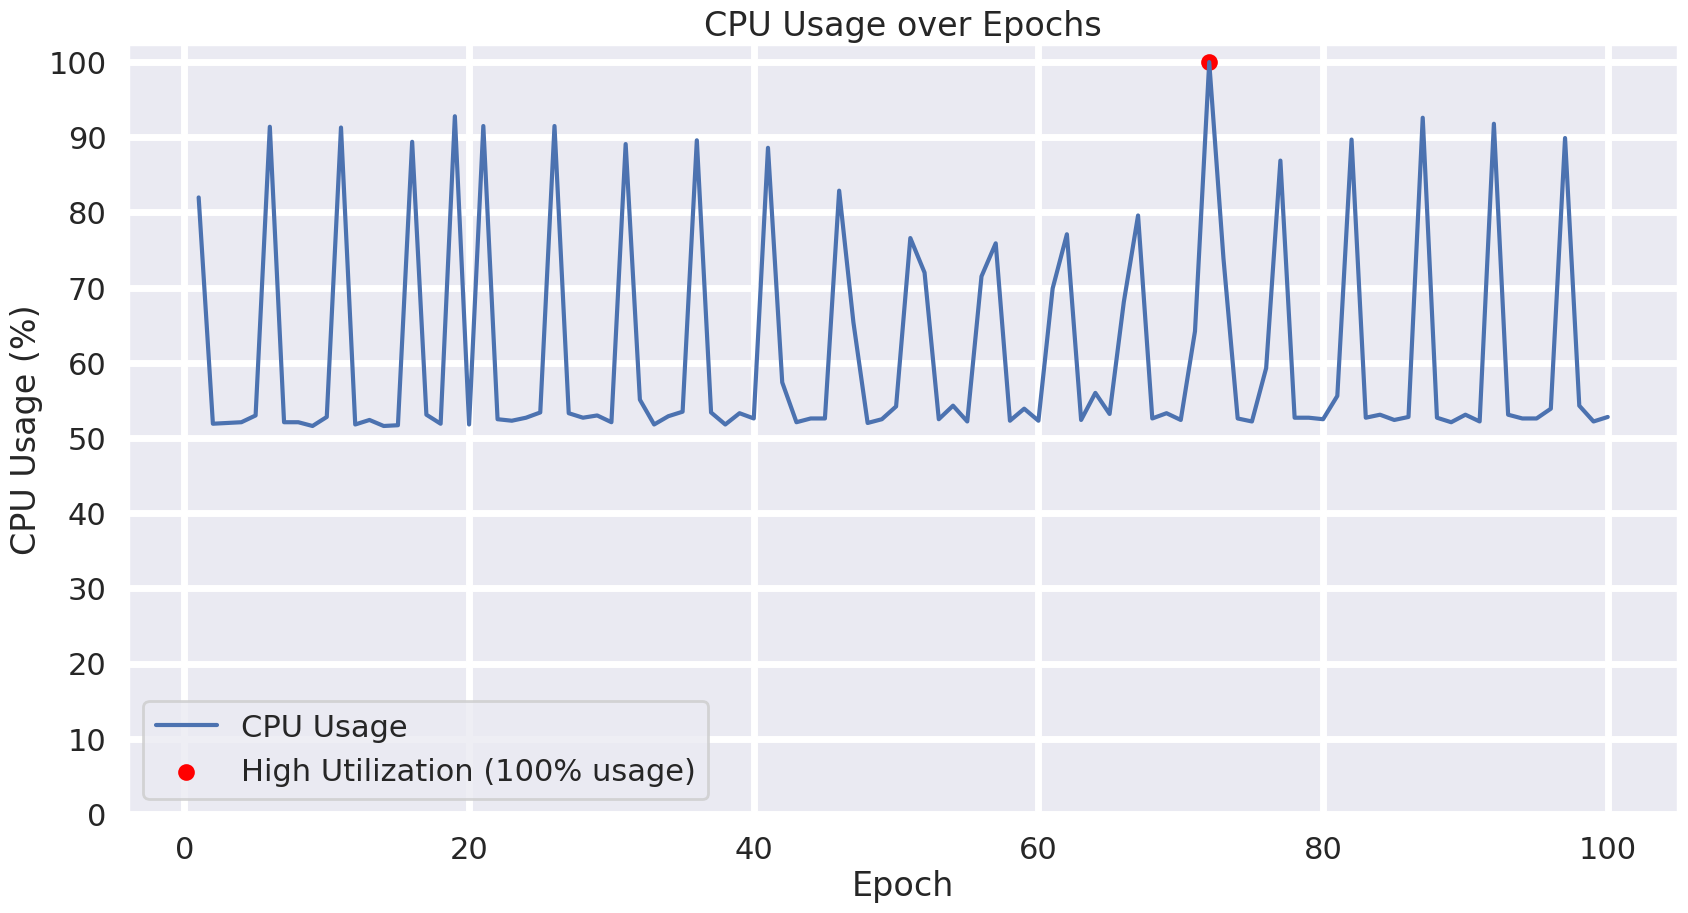

Percentage of High Utilization:  1.0
time: 485 ms (started: 2023-09-02 01:03:16 +00:00)


In [ ]:
# PLOT CPU USAGE

peak_indices, _ = find_peaks(cpu_values, height=100, plateau_size=1)

indices = [i for i in range(len(cpu_values)) if cpu_values[i] == 100.0]

plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, cpu_values, label='CPU Usage')
plt.scatter([epochs[i] for i in indices], [100]*len(indices), color='red', s=100, label='High Utilization (100% usage)')
# plt.scatter([epochs[i] for i in peak_indices], [100]*len(peak_indices), color='blue', s=100, label='Peak of Saturation')
plt.title('CPU Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('CPU Usage (%)')
plt.yticks(range(0, 101, 10))
plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

saturation = (len(indices) / len(epochs)) * 100
print('Percentage of High Utilization: ', saturation)

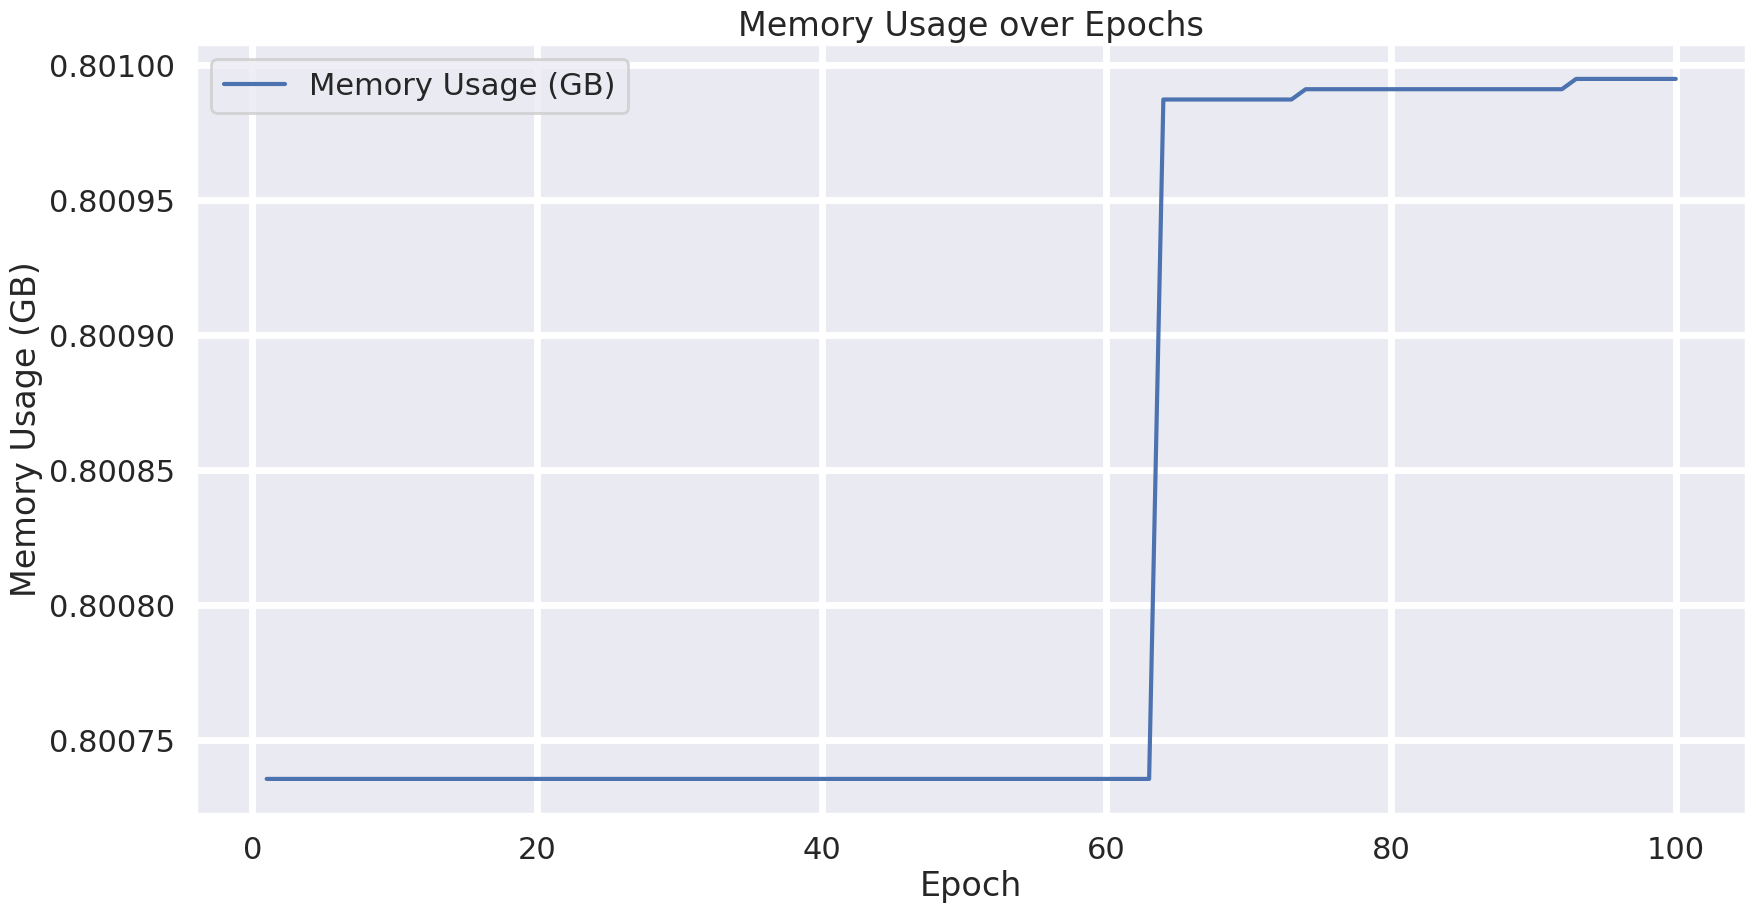

time: 447 ms (started: 2023-09-02 01:03:17 +00:00)


In [ ]:
# PLOT MEMORY USAGE
plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, mem_values, label='Memory Usage (GB)')
plt.title('Memory Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Memory Usage (GB)')
# plt.yticks(range(0, 101, 10))
# plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

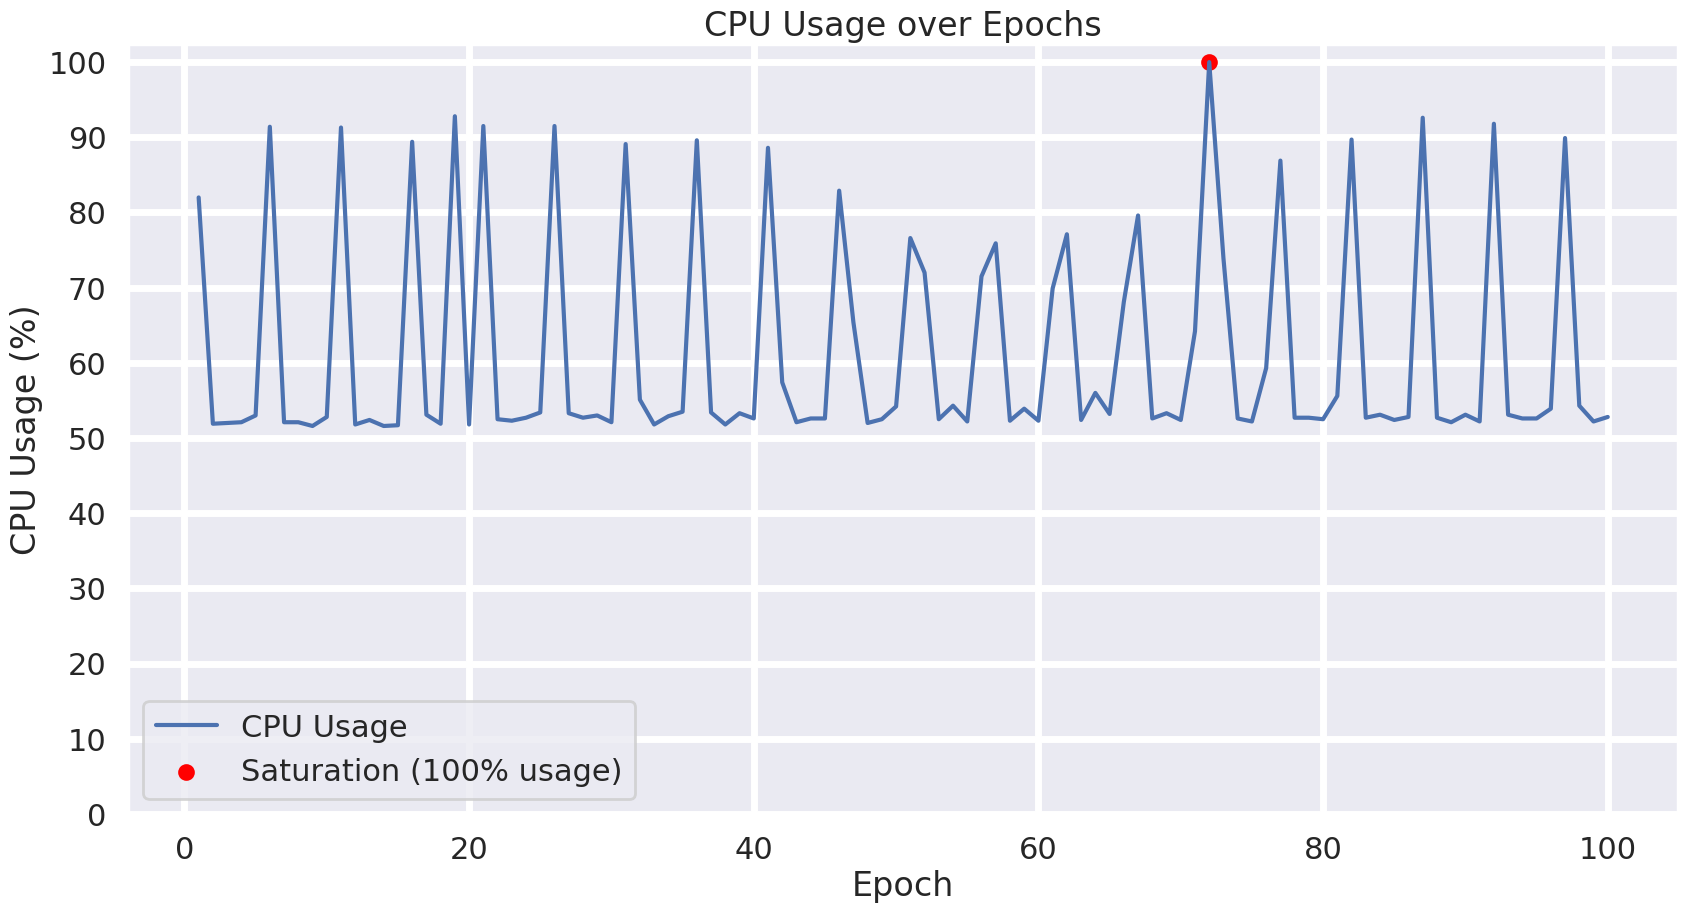

Percentage of High Utilization:  1.0
time: 481 ms (started: 2023-09-02 01:03:17 +00:00)


In [ ]:
# PLOT CPU USAGE

peak_indices, _ = find_peaks(cpu_values, height=100, plateau_size=1)

indices = [i for i in range(len(cpu_values)) if cpu_values[i] == 100.0]

plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, cpu_values, label='CPU Usage')
plt.scatter([epochs[i] for i in indices], [100]*len(indices), color='red', s=100, label='Saturation (100% usage)')
# plt.scatter([epochs[i] for i in peak_indices], [100]*len(peak_indices), color='blue', s=100, label='Peak of Saturation')
plt.title('CPU Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('CPU Usage (%)')
plt.yticks(range(0, 101, 10))
plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

saturation = (len(indices) / len(epochs)) * 100
print('Percentage of High Utilization: ', saturation)

In [ ]:
psutil.cpu_stats()

scpustats(ctx_switches=14285087, interrupts=13246511, soft_interrupts=7794546, syscalls=0)

time: 7.31 ms (started: 2023-09-02 01:03:18 +00:00)


time: 16.9 ms (started: 2023-09-02 01:03:18 +00:00)
